In [1]:
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

import warnings
warnings.filterwarnings('ignore')


In [ ]:
data = pd.read_csv(r'../data/raw/fordgobike-trip_v2.csv')

In [3]:
data.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183412 non-null  int64  
 1   start_time               183412 non-null  str    
 2   end_time                 183412 non-null  str    
 3   start_station_id         183215 non-null  float64
 4   start_station_name       183215 non-null  str    
 5   start_station_latitude   183412 non-null  float64
 6   start_station_longitude  183412 non-null  float64
 7   end_station_id           183215 non-null  float64
 8   end_station_name         183215 non-null  str    
 9   end_station_latitude     183412 non-null  float64
 10  end_station_longitude    183412 non-null  float64
 11  bike_id                  183412 non-null  int64  
 12  user_type                183412 non-null  str    
 13  member_birth_year        175147 non-null  float64
 14  member_gender  

In [5]:
data.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183412.000000,183215.000000,183412.000000,183412.000000,183215.000000,183412.000000,183412.000000,183412.000000,175147.000000
mean,726.078435,138.590427,37.771223,-122.352664,136.249123,37.771427,-122.352250,4472.906375,1984.806437
std,1794.389780,111.778864,0.099581,0.117097,111.515131,0.099490,0.116673,1664.383394,10.116689
min,61.000000,3.000000,37.317298,-122.453704,3.000000,37.317298,-122.453704,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000


In [6]:
data.isna().sum()

duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64

In [7]:
data['start_time'] = pd.to_datetime(data['start_time'], errors='coerce')
data['end_time'] = pd.to_datetime(data['end_time'], errors='coerce')


data['day_of_week'] = data['start_time'].dt.day_name()
data['hour'] = data['start_time'].dt.hour

In [8]:
data.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,day_of_week,hour
0,52185,2019-02-28 17:32:10.145,2019-03-01 08:01:55.975,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No,Thursday,17
1,42521,2019-02-28 18:53:21.789,2019-03-01 06:42:03.056,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No,Thursday,18
2,61854,2019-02-28 12:13:13.218,2019-03-01 05:24:08.146,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No,Thursday,12
3,36490,2019-02-28 17:54:26.010,2019-03-01 04:02:36.842,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No,Thursday,17
4,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes,Thursday,23


In [9]:
impute_mode = SimpleImputer(strategy='most_frequent')
impute_mean = SimpleImputer(strategy='mean')

In [10]:
data[['member_gender']] = impute_mode.fit_transform(data[['member_gender']])
data[['member_birth_year']] = impute_mean.fit_transform(data[['member_birth_year']])
data['member_birth_year'] = data['member_birth_year'].astype(int)

In [11]:
data.dropna(subset=['start_station_id', 'end_station_id'], inplace=True)


In [12]:
data.isna().sum()

duration_sec               0
start_time                 0
end_time                   0
start_station_id           0
start_station_name         0
start_station_latitude     0
start_station_longitude    0
end_station_id             0
end_station_name           0
end_station_latitude       0
end_station_longitude      0
bike_id                    0
user_type                  0
member_birth_year          0
member_gender              0
bike_share_for_all_trip    0
day_of_week                0
hour                       0
dtype: int64

In [13]:
data.info()

<class 'pandas.DataFrame'>
Index: 183215 entries, 0 to 183411
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   duration_sec             183215 non-null  int64         
 1   start_time               183215 non-null  datetime64[us]
 2   end_time                 183215 non-null  datetime64[us]
 3   start_station_id         183215 non-null  float64       
 4   start_station_name       183215 non-null  str           
 5   start_station_latitude   183215 non-null  float64       
 6   start_station_longitude  183215 non-null  float64       
 7   end_station_id           183215 non-null  float64       
 8   end_station_name         183215 non-null  str           
 9   end_station_latitude     183215 non-null  float64       
 10  end_station_longitude    183215 non-null  float64       
 11  bike_id                  183215 non-null  int64         
 12  user_type                183215 

In [14]:
data.duplicated().sum()

np.int64(0)

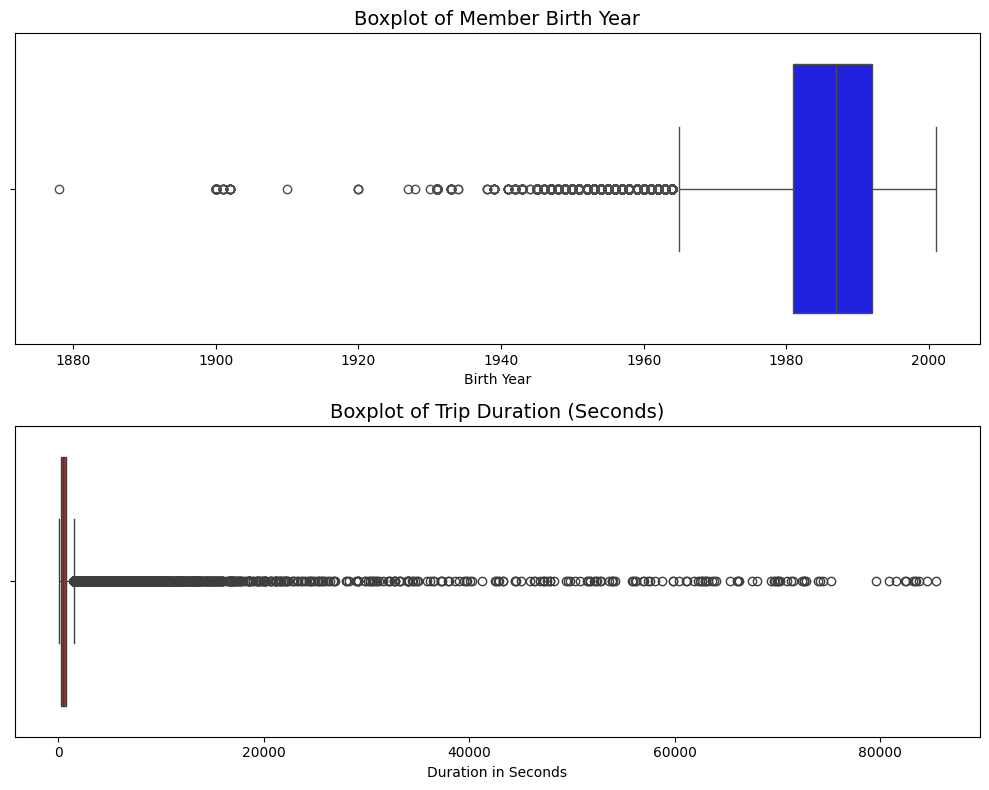

In [15]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1) 
sns.boxplot(x=data['member_birth_year'], color='blue')
plt.title("Boxplot of Member Birth Year", fontsize=14)
plt.xlabel("Birth Year")

plt.subplot(2, 1, 2) 
sns.boxplot(x=data['duration_sec'], color='brown')
plt.title("Boxplot of Trip Duration (Seconds)", fontsize=14)
plt.xlabel("Duration in Seconds")

plt.tight_layout()
plt.show()

In [16]:
Q1_dur = data['duration_sec'].quantile(0.25)
Q3_dur = data['duration_sec'].quantile(0.75)

IQR_dur = Q3_dur - Q1_dur

lower_bound_dur = Q1_dur - 1.5 * IQR_dur
upper_bound_dur = Q3_dur + 1.5 * IQR_dur

data = data[(data['duration_sec'] >= lower_bound_dur) & (data['duration_sec'] <= upper_bound_dur)]


Q1_birth = data['member_birth_year'].quantile(0.25)
Q3_birth = data['member_birth_year'].quantile(0.75)

IQR_birth = Q3_birth - Q1_birth

lower_bound_birth = Q1_birth - 1.5 * IQR_birth
upper_bound_birth = Q3_birth + 1.5 * IQR_birth

data = data[(data['member_birth_year'] >= lower_bound_birth) & (data['member_birth_year'] <= upper_bound_birth)]


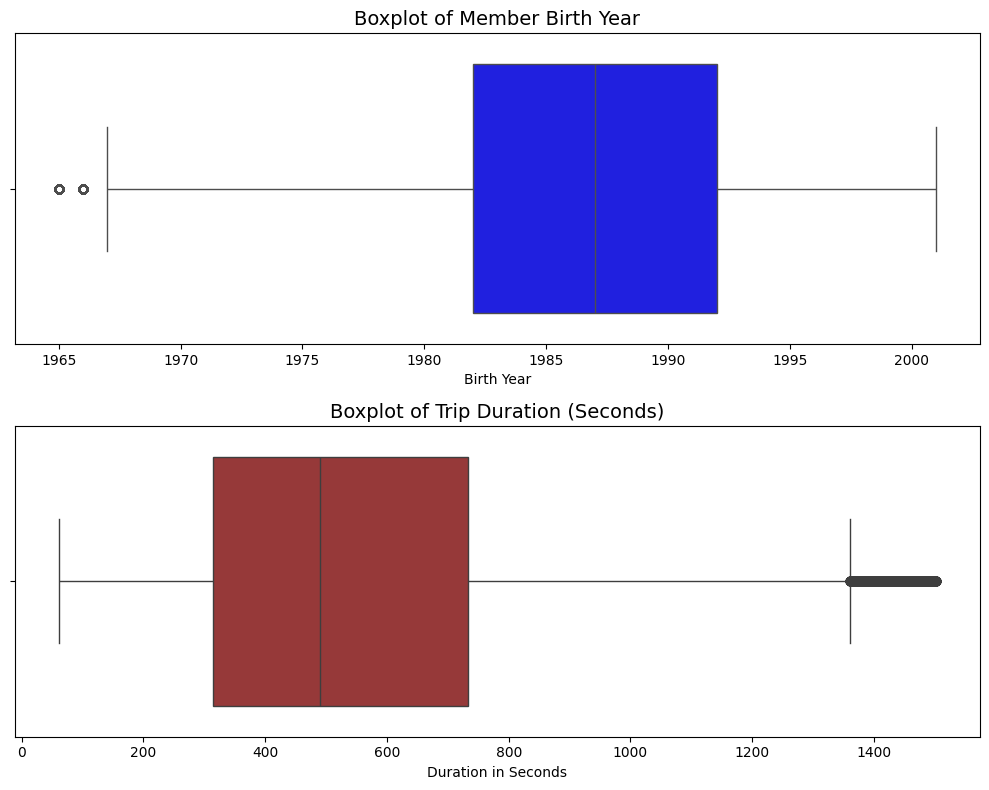

In [17]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1) 
sns.boxplot(x=data['member_birth_year'], color='blue')
plt.title("Boxplot of Member Birth Year", fontsize=14)
plt.xlabel("Birth Year")

plt.subplot(2, 1, 2) 
sns.boxplot(x=data['duration_sec'], color='brown')
plt.title("Boxplot of Trip Duration (Seconds)", fontsize=14)
plt.xlabel("Duration in Seconds")

plt.tight_layout()
plt.show()

In [18]:
data.info()

<class 'pandas.DataFrame'>
Index: 164783 entries, 6 to 183411
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   duration_sec             164783 non-null  int64         
 1   start_time               164783 non-null  datetime64[us]
 2   end_time                 164783 non-null  datetime64[us]
 3   start_station_id         164783 non-null  float64       
 4   start_station_name       164783 non-null  str           
 5   start_station_latitude   164783 non-null  float64       
 6   start_station_longitude  164783 non-null  float64       
 7   end_station_id           164783 non-null  float64       
 8   end_station_name         164783 non-null  str           
 9   end_station_latitude     164783 non-null  float64       
 10  end_station_longitude    164783 non-null  float64       
 11  bike_id                  164783 non-null  int64         
 12  user_type                164783 

In [19]:
data.describe()

,duration_sec,start_time,end_time,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year,hour
count,164783.000000,164783,164783,164783.000000,164783.000000,164783.000000,164783.000000,164783.000000,164783.000000,164783.000000,164783.000000,164783.000000
mean,552.699308,2019-02-15 20:01:53.842230,2019-02-15 20:11:07.040505,138.688147,37.770843,-122.351866,135.630745,37.771021,-122.351330,4488.066833,1986.152971,13.455727
min,61.000000,2019-02-01 00:00:20.636000,2019-02-01 00:04:52.058000,3.000000,37.317298,-122.453704,3.000000,37.317298,-122.453704,11.000000,1965.000000,0.000000
25%,315.000000,2019-02-08 07:51:49.635000,2019-02-08 08:01:01.418000,49.000000,37.770083,-122.411901,44.000000,37.770407,-122.411403,3824.000000,1982.000000,9.000000
50%,490.000000,2019-02-15 18:31:10.571000,2019-02-15 18:40:44.556000,104.000000,37.780526,-122.398285,100.000000,37.780760,-122.397437,4962.000000,1987.000000,14.000000
75%,733.000000,2019-02-22 10:02:05.430000,2019-02-22 10:12:12.855000,239.000000,37.797280,-122.283093,232.000000,37.797280,-122.287180,5504.000000,1992.000000,17.000000
max,1502.000000,2019-02-28 23:59:18.548000,2019-03-01 00:14:42.588000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000,23.000000
std,305.594684,NaN,NaN,110.971667,0.100699,0.117946,110.245590,0.100602,0.117454,1654.840365,7.767070,4.770030


In [20]:
data['user_type'] = data['user_type'].astype('category')
data['member_gender'] = data['member_gender'].astype('category')
data['bike_share_for_all_trip'] = data['bike_share_for_all_trip'].astype('category')
data['start_station_name'] = data['start_station_name'].astype('category')
data['end_station_name'] = data['end_station_name'].astype('category')


In [21]:
data.info()

<class 'pandas.DataFrame'>
Index: 164783 entries, 6 to 183411
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   duration_sec             164783 non-null  int64         
 1   start_time               164783 non-null  datetime64[us]
 2   end_time                 164783 non-null  datetime64[us]
 3   start_station_id         164783 non-null  float64       
 4   start_station_name       164783 non-null  category      
 5   start_station_latitude   164783 non-null  float64       
 6   start_station_longitude  164783 non-null  float64       
 7   end_station_id           164783 non-null  float64       
 8   end_station_name         164783 non-null  category      
 9   end_station_latitude     164783 non-null  float64       
 10  end_station_longitude    164783 non-null  float64       
 11  bike_id                  164783 non-null  int64         
 12  user_type                164783 

In [22]:
data['duration_min'] = data['duration_sec'] / 60
data['member_age'] = 2019 - data['member_birth_year']

years = [0, 25, 45, 65, 120]  
group = ['Youth', 'Adults', 'Middle-aged', 'Elderly']

data['age_group'] = pd.cut(data['member_age'], bins=years, labels=group)

In [23]:
data.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,day_of_week,hour,duration_min,member_age,age_group
6,1147,2019-02-28 23:55:35.104,2019-03-01 00:14:42.588,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,...,3803,Subscriber,1983,Female,No,Thursday,23,19.116667,36,Adults
9,1049,2019-02-28 23:49:47.699,2019-03-01 00:07:17.025,19.0,Post St at Kearny St,37.788975,-122.403452,121.0,Mission Playground,37.759210,...,6488,Subscriber,1992,Male,No,Thursday,23,17.483333,27,Adults
10,458,2019-02-28 23:57:57.211,2019-03-01 00:05:35.435,370.0,Jones St at Post St,37.787327,-122.413278,43.0,San Francisco Public Library (Grove St at Hyde...,37.778768,...,5318,Subscriber,1996,Female,Yes,Thursday,23,7.633333,23,Youth
11,506,2019-02-28 23:56:55.540,2019-03-01 00:05:21.733,44.0,Civic Center/UN Plaza BART Station (Market St ...,37.781074,-122.411738,343.0,Bryant St at 2nd St,37.783172,...,5848,Subscriber,1993,Male,No,Thursday,23,8.433333,26,Adults
12,1176,2019-02-28 23:45:12.651,2019-03-01 00:04:49.184,127.0,Valencia St at 21st St,37.756708,-122.421025,323.0,Broadway at Kearny,37.798014,...,5328,Customer,1990,Male,No,Thursday,23,19.600000,29,Adults


In [24]:
ord_enc = OrdinalEncoder()
data[['user_type_encoded', 'bike_share_encoded']] = ord_enc.fit_transform(data[['user_type', 'bike_share_for_all_trip']])

ohe = OneHotEncoder(sparse_output=False)
gender_encoded = ohe.fit_transform(data[['member_gender']])

pd.DataFrame(gender_encoded, columns=ohe.get_feature_names_out(['member_gender']))
data = pd.get_dummies(data, columns=['member_gender'])

In [25]:
data.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,day_of_week,hour,duration_min,member_age,age_group,user_type_encoded,bike_share_encoded,member_gender_Female,member_gender_Male,member_gender_Other
6,1147,2019-02-28 23:55:35.104,2019-03-01 00:14:42.588,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,...,Thursday,23,19.116667,36,Adults,1.0,0.0,True,False,False
9,1049,2019-02-28 23:49:47.699,2019-03-01 00:07:17.025,19.0,Post St at Kearny St,37.788975,-122.403452,121.0,Mission Playground,37.759210,...,Thursday,23,17.483333,27,Adults,1.0,0.0,False,True,False
10,458,2019-02-28 23:57:57.211,2019-03-01 00:05:35.435,370.0,Jones St at Post St,37.787327,-122.413278,43.0,San Francisco Public Library (Grove St at Hyde...,37.778768,...,Thursday,23,7.633333,23,Youth,1.0,1.0,True,False,False
11,506,2019-02-28 23:56:55.540,2019-03-01 00:05:21.733,44.0,Civic Center/UN Plaza BART Station (Market St ...,37.781074,-122.411738,343.0,Bryant St at 2nd St,37.783172,...,Thursday,23,8.433333,26,Adults,1.0,0.0,False,True,False
12,1176,2019-02-28 23:45:12.651,2019-03-01 00:04:49.184,127.0,Valencia St at 21st St,37.756708,-122.421025,323.0,Broadway at Kearny,37.798014,...,Thursday,23,19.600000,29,Adults,0.0,0.0,False,True,False


In [26]:
data.info()

<class 'pandas.DataFrame'>
Index: 164783 entries, 6 to 183411
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   duration_sec             164783 non-null  int64         
 1   start_time               164783 non-null  datetime64[us]
 2   end_time                 164783 non-null  datetime64[us]
 3   start_station_id         164783 non-null  float64       
 4   start_station_name       164783 non-null  category      
 5   start_station_latitude   164783 non-null  float64       
 6   start_station_longitude  164783 non-null  float64       
 7   end_station_id           164783 non-null  float64       
 8   end_station_name         164783 non-null  category      
 9   end_station_latitude     164783 non-null  float64       
 10  end_station_longitude    164783 non-null  float64       
 11  bike_id                  164783 non-null  int64         
 12  user_type                164783 

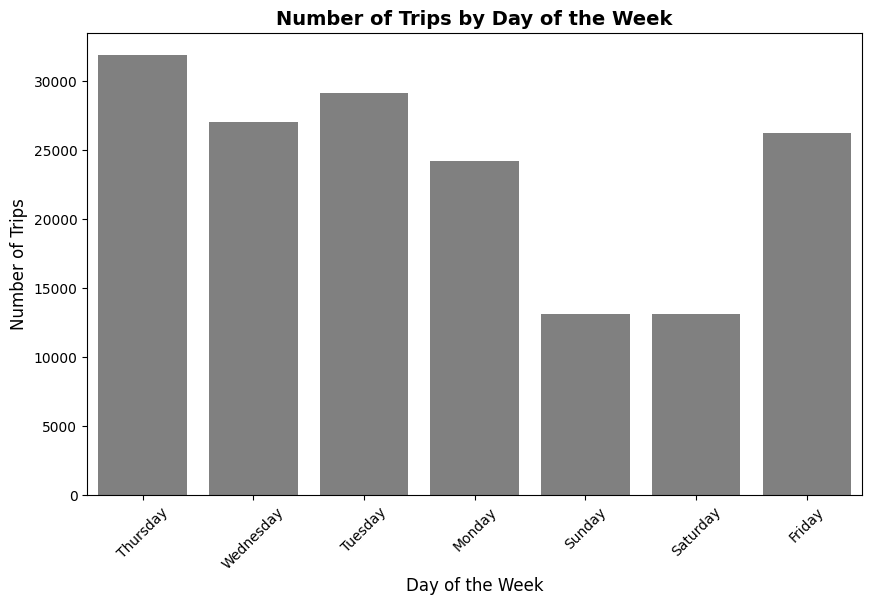

In [31]:
plt.figure(figsize=[10, 6])
sns.countplot(data=data, x='day_of_week', color='grey')
plt.title('Number of Trips by Day of the Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.xticks(rotation=45)
plt.show()

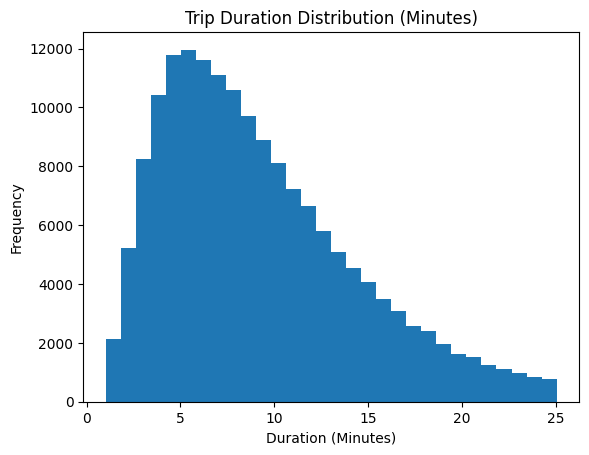

In [27]:
plt.figure()
plt.hist(data['duration_min'], bins=30)
plt.title("Trip Duration Distribution (Minutes)")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Frequency")
plt.show()

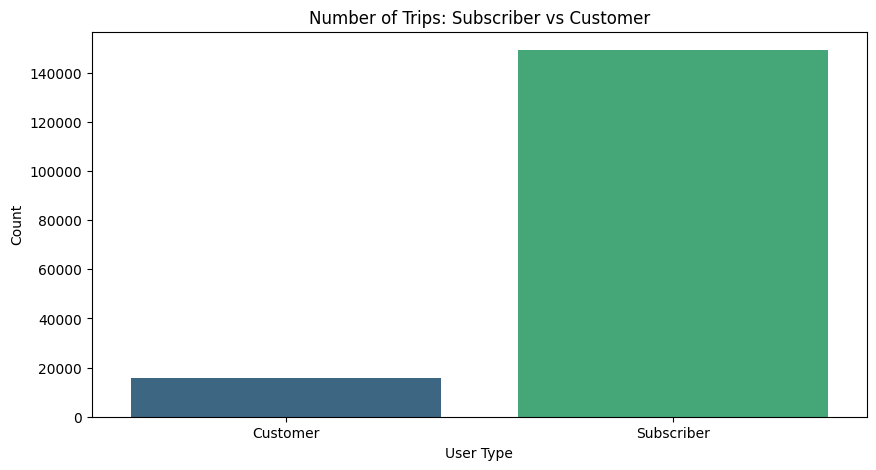

In [28]:
plt.figure(figsize=[10,5])
sns.countplot(data, x='user_type', palette='viridis')
plt.title('Number of Trips: Subscriber vs Customer')
plt.xlabel('User Type')
plt.ylabel('Count')
plt.show()

In [ ]:
data.to_csv('../data/processed/bike_data_cleaned.csv', index=False)